In [88]:
import numpy as np
import matplotlib.pyplot as plt
import gzip
import time

# Data Pre-processing

In [2]:
with gzip.open('./data/MNIST/raw/t10k-images-idx3-ubyte.gz') as file:
    print(np.frombuffer(file.read(64)).shape)

(8,)


In [13]:
def read_idx_images(filepath):
    with gzip.open(filepath, 'rb') as f:

        header = np.frombuffer(f.read(16), dtype='>i4')  
        magic, num_images, rows, cols = header


        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(num_images, rows, cols)
    return images

def read_idx_labels(filepath):
    with gzip.open(filepath, 'rb') as f:

        header = np.frombuffer(f.read(8), dtype='>i4')
        magic, num_labels = header

        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [121]:
train_images = read_idx_images("data/MNIST/raw/train-images-idx3-ubyte.gz")
train_labels = read_idx_labels("data/MNIST/raw/train-labels-idx1-ubyte.gz")

test_images = read_idx_images("data/MNIST/raw/t10k-images-idx3-ubyte.gz")
test_labels = read_idx_labels("data/MNIST/raw/t10k-labels-idx1-ubyte.gz")

In [122]:
print(train_images.shape)
print(train_labels.shape)

print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [123]:
train_images = train_images / np.max(train_images)
test_images = test_images / np.max(test_images)

In [124]:
mean = np.mean(train_images)
std = np.std(train_images)

In [125]:
print(mean)
print(std)

0.1306604762738429
0.30810780385646264


In [126]:
train_data = (train_images - mean) / std
test_data = (test_images - mean) / std

In [127]:
train_data.shape

(60000, 28, 28)

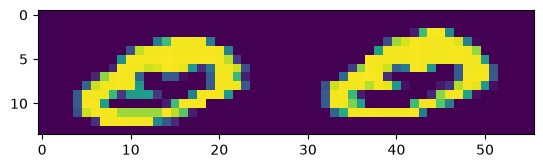

In [128]:
plt.imshow(train_data[63].reshape(14, 56))

In [130]:
np.random.permutation(60000)[:64]

array([44939, 45767, 25043, 27563, 17987, 24075,  1203,  2245, 40777,
       21659,  5641, 21615, 48866,  1020, 57579, 37201,  4825, 56508,
       26572, 13467, 37051, 42466, 12517, 31833, 25731, 18351, 51983,
        8409, 48480, 58384, 48090, 50139, 32549, 57844, 49345, 27170,
       59236, 16720, 41363, 40871, 51818, 44645, 38727, 56221, 29607,
        6334, 14780, 11688, 25806,  7857, 31312, 59953, 52709, 17590,
       40806,  1523, 51534, 38910, 39144, 45634,  5313,  2187, 52349,
       53388])

In [155]:
batch = np.random.permutation(60000)[:64]

Text(0.5, 1.0, '2')

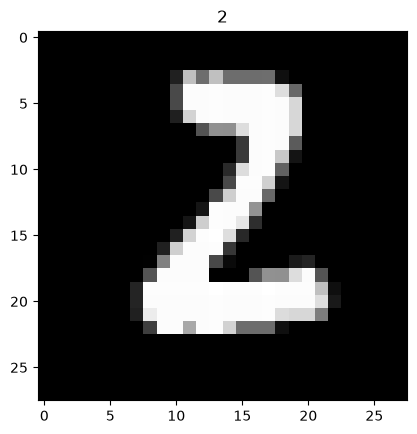

In [166]:
data = train_data[batch][:64]
idx = 20
plt.imshow(data[idx], cmap='gray')
plt.title(train_labels[batch][:64][idx])

In [167]:
train_data.shape

(60000, 28, 28)

# Model declaration

In [185]:
def ReLU(x):
    x[x < 0] = 0
    return x

In [ ]:
class MNIST:
    def __init__(self):
        self.W1 = np.random.random((64, 784))
        self.b1 = np.random.random((64, 1))
        self.W2 = np.random.random((10, 64))
        self.b2 = np.random.random((10, 1))

    def forward(self, x):
        x = x.reshape(64, 784)
        x = x @ self.W1.T + self.b1
        x = ReLU(x)
        x = x @ self.W2.T + self.b2

        return x
